# Notebook 05 — Real-World Application: Airline Fuel Hedging with Asian Options

**Option Pricing Horizon** | Task 5 of 5

---

## Economic Motivation

Jet fuel is the single largest operating cost for airlines — typically **20–30 % of
total operating expenses**.  Fuel prices are highly volatile and correlated with
crude oil prices ($\sigma \approx 30\text{–}40\%$ annualised).

**The hedging problem:**  An airline knows it will purchase jet fuel every month
over the next year.  It wants to cap its **average monthly fuel cost** over the
coming year while still benefiting if prices fall.

**Why an Asian call option?**
- The airline's actual fuel cost is the **average price** paid over 12 monthly purchases
- An Asian call pays off when the average price exceeds the budget price (strike)
- It is **cheaper** than a European vanilla call on the terminal price
- It is **less manipulable** — no single expiry date that can be squeezed
- The averaging feature **reduces the effective volatility**, lowering the premium

**Why NOT a vanilla European call?**
- A European call only protects against the *terminal* price, not the average
- If prices spike mid-year and fall at expiry, a European call pays nothing
  but the airline has already paid high prices during the year

---

## Case Design: Delta Airlines-Style Quarterly Fuel Hedge

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | Jet fuel (Brent-based) | Standard benchmark |
| S₀ | $2.80/gallon | Approximate 2024 spot |
| K (budget cap) | $3.00/gallon | Budget strike (+7.1% OTM) |
| σ | 35% | Historical jet fuel vol |
| r | 5% | USD risk-free (Fed Funds) |
| T | 1 year | Annual hedging horizon |
| N | 12 | Monthly monitoring |
| Quantity | 400M gallons | Large airline annual usage |

The airline buys one **arithmetic Asian call** on average monthly jet fuel price.
At maturity the payoff (per gallon) = max(A_arith − $3.00, 0).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from option_pricing_horizon.common.market_params import MarketParams
from option_pricing_horizon.asian.monte_carlo import arithmetic_asian_mc
from option_pricing_horizon.asian.geometric import geometric_asian_call
from option_pricing_horizon.european.black_scholes import bs_call_price
from option_pricing_horizon.common.simulation import simulate_gbm_paths
from option_pricing_horizon.asian.payoffs import arithmetic_average_payoff

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

# ─── Airline hedging parameters ──────────────────────────────────────────
S0     = 2.80    # Spot jet fuel price ($/gallon)
K      = 3.00    # Budget strike ($/gallon)
r      = 0.05    # USD risk-free rate
sigma  = 0.35    # Jet fuel annualised volatility
T      = 1.0     # 1-year hedge
N      = 12      # Monthly monitoring dates
qty    = 400e6   # Gallons per year

mp_airline = MarketParams(S0=S0, K=K, r=r, sigma=sigma, T=T, N=N)
print(mp_airline)
print(f"\nAnnual fuel quantity: {qty/1e6:.0f}M gallons")
print(f"Unhedged annual fuel cost at spot: ${S0*qty/1e6:.0f}M")
print(f"Budget cap at K=${K}: ${K*qty/1e6:.0f}M")

MarketParams(S0=2.8, K=3.0, r=0.05, sigma=0.35, T=1.0, N=12, q=0.0)

Annual fuel quantity: 400M gallons
Unhedged annual fuel cost at spot: $1120M
Budget cap at K=$3.0: $1200M


## 1. Pricing the Asian Call vs European Vanilla

We compare the **arithmetic Asian call** (what the airline actually needs) with:
- The **geometric Asian call** (cheaper still, as analytical lower bound)
- The **European vanilla call** (more expensive, wrong payoff structure)

In [2]:
# Price all three products
print("Pricing options... (MC 200k paths)")
arith_result = arithmetic_asian_mc(
    S0, K, r, sigma, T, N=N, n_paths=200_000, seed=42,
    option_type='call', use_cv=True, use_antithetic=True
)
geo_price     = geometric_asian_call(S0, K, r, sigma, T, N)
vanilla_price = bs_call_price(S0, K, r, sigma, T)

# Per-gallon and total cost
arith_premium_pgal = arith_result.price
geo_premium_pgal   = geo_price
van_premium_pgal   = vanilla_price

arith_total = arith_premium_pgal * qty
geo_total   = geo_premium_pgal   * qty
van_total   = van_premium_pgal   * qty

print(f"\n{'='*65}")
print(f"  Option Pricing Results — Airline Fuel Hedge")
print(f"  S₀=${S0}, K=${K}, r={r:.0%}, σ={sigma:.0%}, T={T}yr, N={N} months")
print(f"{'='*65}")
print(f"  Product                     Premium/gal    Total Premium")
print(f"  {'-'*55}")
print(f"  Arithmetic Asian Call       ${arith_premium_pgal:.4f}/gal   ${arith_total/1e6:.2f}M")
print(f"  Geometric Asian Call        ${geo_premium_pgal:.4f}/gal   ${geo_total/1e6:.2f}M")
print(f"  European Vanilla Call       ${van_premium_pgal:.4f}/gal   ${van_total/1e6:.2f}M")
print(f"{'='*65}")
print(f"\n  Savings from Asian vs Vanilla: ${(van_total - arith_total)/1e6:.2f}M  "
      f"({(van_total - arith_total)/van_total:.1%} cheaper)")
print(f"  95% CI on Asian price: [${arith_result.ci_lower:.4f}, ${arith_result.ci_upper:.4f}]")
print(f"  Variance reduction ratio: {arith_result.variance_reduction_ratio:.1f}x")
print(f"\n  Interpretation:")
print(f"  The airline pays ${arith_total/1e6:.1f}M for the Asian cap vs ${van_total/1e6:.1f}M")
print(f"  for an equivalent vanilla cap — saving ${(van_total-arith_total)/1e6:.1f}M in premium.")
print(f"  The Asian option is the correct hedge because the airline's exposure")
print(f"  is to the AVERAGE monthly price, not the terminal price.")

Pricing options... (MC 200k paths)

  Option Pricing Results — Airline Fuel Hedge
  S₀=$2.8, K=$3.0, r=5%, σ=35%, T=1.0yr, N=12 months
  Product                     Premium/gal    Total Premium
  -------------------------------------------------------
  Arithmetic Asian Call       $0.1868/gal   $74.72M
  Geometric Asian Call        $0.1723/gal   $68.92M
  European Vanilla Call       $0.3664/gal   $146.57M

  Savings from Asian vs Vanilla: $71.85M  (49.0% cheaper)
  95% CI on Asian price: [$0.1867, $0.1869]
  Variance reduction ratio: 330.5x

  Interpretation:
  The airline pays $74.7M for the Asian cap vs $146.6M
  for an equivalent vanilla cap — saving $71.9M in premium.
  The Asian option is the correct hedge because the airline's exposure
  is to the AVERAGE monthly price, not the terminal price.


## 2. Payoff Scenarios: Hedged vs Unhedged Fuel Cost

We simulate fuel cost outcomes with and without the Asian call hedge.

In [3]:
n_paths = 100_000
paths   = simulate_gbm_paths(S0, r, sigma, T, N, n_paths, seed=42, antithetic=True)
disc    = np.exp(-r * T)

# Average monthly price per scenario
A_arith = paths.mean(axis=1)   # $/gallon average over 12 months

# Unhedged total fuel cost (present value)
unhedged_cost = A_arith * qty   # total $ (not discounted for clarity)

# Asian call payoff (offsets costs above K)
asian_payoff = np.maximum(A_arith - K, 0.0) * qty

# Hedged cost = actual cost - option payoff + premium paid
hedged_cost = unhedged_cost - asian_payoff + arith_premium_pgal * qty

# Vanilla European: payoff based on terminal price only
S_T         = paths[:, -1]
van_payoff  = np.maximum(S_T - K, 0.0) * qty
van_hedged  = unhedged_cost - van_payoff + vanilla_price * qty

# Statistics
def stats(x, name):
    return {
        'Strategy': name,
        'Mean ($M)':   round(x.mean()   / 1e6, 2),
        'Std Dev ($M)': round(x.std()   / 1e6, 2),
        '5th pctile ($M)':  round(np.percentile(x, 5)  / 1e6, 2),
        '95th pctile ($M)': round(np.percentile(x, 95) / 1e6, 2),
        'VaR 95% ($M)': round((np.percentile(x, 95) - x.mean()) / 1e6, 2),
    }

stats_df = pd.DataFrame([
    stats(unhedged_cost, 'Unhedged'),
    stats(hedged_cost,   'Asian Call Hedged'),
    stats(van_hedged,    'Vanilla Call Hedged'),
]).set_index('Strategy')

print("Fuel Cost Statistics (100k scenarios, $/M = millions)")
print(stats_df.to_string())
print("\nKey observations:")
print(f"  • Asian hedge reduces std dev by "
      f"{(1 - hedged_cost.std()/unhedged_cost.std())*100:.1f}% vs unhedged")
print(f"  • Vanilla hedge reduces std dev by "
      f"{(1 - van_hedged.std()/unhedged_cost.std())*100:.1f}% vs unhedged")
print(f"  • Asian option provides tighter cost cap due to payoff alignment")

Fuel Cost Statistics (100k scenarios, $/M = millions)
                     Mean ($M)  Std Dev ($M)  5th pctile ($M)  95th pctile ($M)  VaR 95% ($M)
Strategy                                                                                     
Unhedged               1150.72        251.58           796.93           1607.03        456.31
Asian Call Hedged      1147.22        142.45           871.64           1274.72        127.50
Vanilla Call Hedged    1144.08        187.06           843.96           1421.43        277.35

Key observations:
  • Asian hedge reduces std dev by 43.4% vs unhedged
  • Vanilla hedge reduces std dev by 25.6% vs unhedged
  • Asian option provides tighter cost cap due to payoff alignment


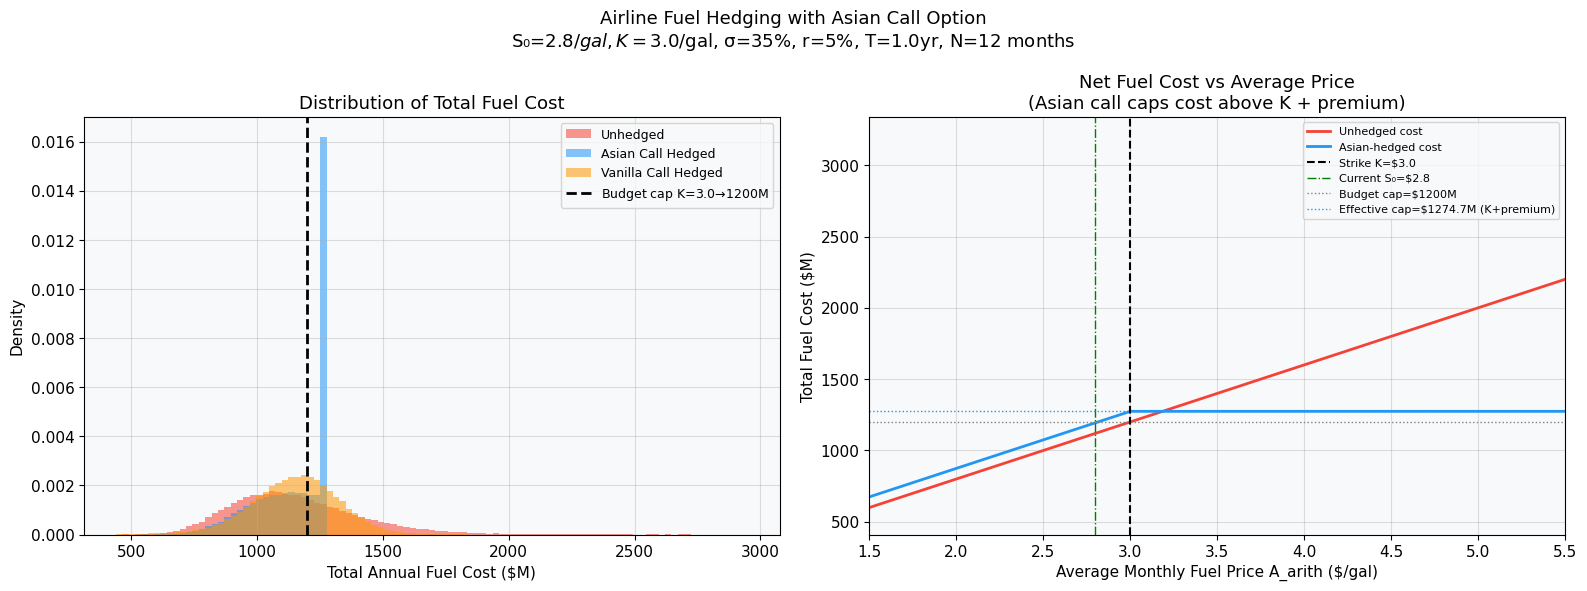

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Airline Fuel Hedging with Asian Call Option\n'
             f'S₀=${S0}/gal, K=${K}/gal, σ={sigma:.0%}, r={r:.0%}, T={T}yr, N={N} months',
             fontsize=13)

# Distribution of total fuel costs
bins = np.linspace(
    min(unhedged_cost.min(), hedged_cost.min()) / 1e6,
    max(unhedged_cost.max(), hedged_cost.max()) / 1e6 * 0.92,
    100
)
axes[0].hist(unhedged_cost / 1e6, bins=bins, density=True, alpha=0.55,
             color='#F44336', label='Unhedged')
axes[0].hist(hedged_cost   / 1e6, bins=bins, density=True, alpha=0.55,
             color='#2196F3', label='Asian Call Hedged')
axes[0].hist(van_hedged    / 1e6, bins=bins, density=True, alpha=0.55,
             color='#FF9800', label='Vanilla Call Hedged')
axes[0].axvline(K * qty / 1e6, color='black', lw=2, ls='--',
                label=f'Budget cap K=${K} → ${K*qty/1e6:.0f}M')
axes[0].set_xlabel('Total Annual Fuel Cost ($M)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Total Fuel Cost')
axes[0].legend(fontsize=9)

# Net cost vs average price
A_sorted = np.sort(A_arith[:5000])
uc_s     = (A_sorted * qty) / 1e6
ac_s     = (np.maximum(A_sorted - K, 0) * qty) / 1e6   # payoff
hedged_s = uc_s - ac_s + arith_premium_pgal * qty / 1e6

axes[1].plot(A_sorted, uc_s,     color='#F44336', lw=2,   label='Unhedged cost')
axes[1].plot(A_sorted, hedged_s, color='#2196F3', lw=2,   label='Asian-hedged cost')
axes[1].axvline(K,   color='black', lw=1.5, ls='--', label=f'Strike K=${K}')
axes[1].axvline(S0,  color='green', lw=1,   ls='-.', label=f'Current S₀=${S0}')
axes[1].axhline(K * qty / 1e6, color='grey', lw=1, ls=':', label=f'Budget cap=${K*qty/1e6:.0f}M')
# Effective cap line
cap_level = (K * qty + arith_premium_pgal * qty) / 1e6
axes[1].axhline(cap_level, color='#2196F3', lw=1, ls=':',
                label=f'Effective cap=${cap_level:.1f}M (K+premium)')
axes[1].set_xlabel('Average Monthly Fuel Price A_arith ($/gal)')
axes[1].set_ylabel('Total Fuel Cost ($M)')
axes[1].set_title('Net Fuel Cost vs Average Price\n(Asian call caps cost above K + premium)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(1.5, 5.5)

plt.tight_layout()
plt.show()

## 3. Parameter Sensitivity for the Airline Case

Computing sensitivity to σ and K (30k paths each)...
Done.


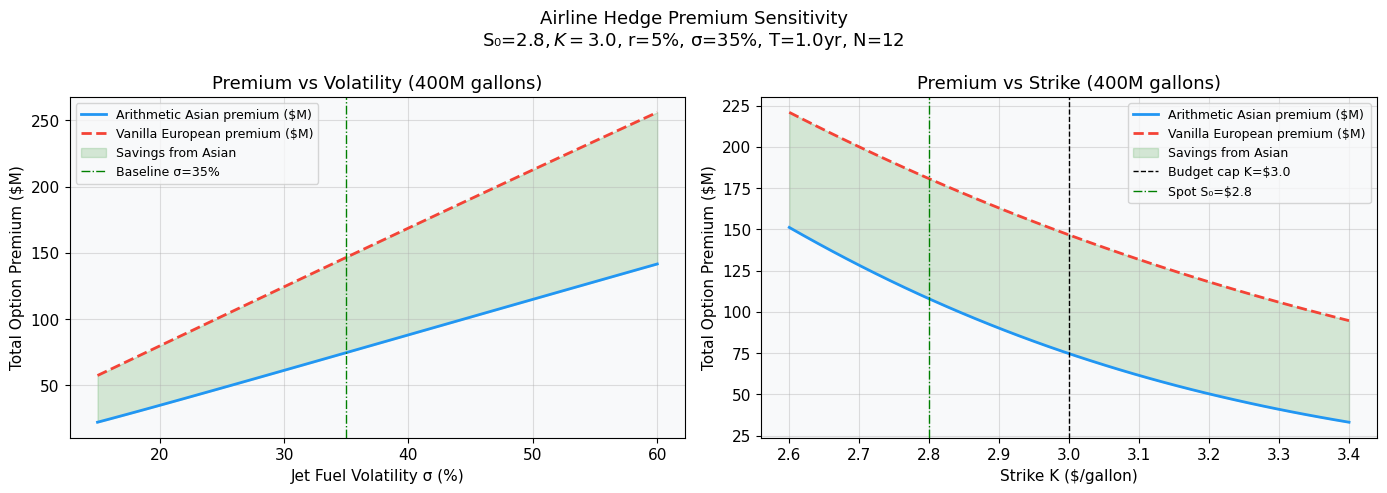

In [5]:
# Sensitivity to volatility and strike (the two most important parameters for the airline)
sigma_range = np.linspace(0.15, 0.60, 40)
K_range     = np.linspace(2.60, 3.40, 40)

def airline_price(S, K_, r_, sigma_, T_, N_, n_paths_=30_000):
    res = arithmetic_asian_mc(S, K_, r_, sigma_, T_, N=N_,
                               n_paths=n_paths_, seed=42, use_cv=True, use_antithetic=True)
    return res.price

print("Computing sensitivity to σ and K (30k paths each)...")
prices_sigma = np.array([airline_price(S0, K, r, s, T, N) for s in sigma_range])
prices_K     = np.array([airline_price(S0, k, r, sigma, T, N) for k in K_range])
van_sigma    = np.array([bs_call_price(S0, K, r, s, T)  for s in sigma_range])
van_K        = np.array([bs_call_price(S0, k, r, sigma, T) for k in K_range])
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Airline Hedge Premium Sensitivity\n'
             f'S₀=${S0}, K=${K}, r={r:.0%}, σ={sigma:.0%}, T={T}yr, N={N}',
             fontsize=13)

axes[0].plot(sigma_range * 100, prices_sigma * qty / 1e6, color='#2196F3', lw=2,
             label='Arithmetic Asian premium ($M)')
axes[0].plot(sigma_range * 100, van_sigma * qty / 1e6,    color='#F44336', lw=2, ls='--',
             label='Vanilla European premium ($M)')
axes[0].fill_between(sigma_range * 100,
                     prices_sigma * qty / 1e6, van_sigma * qty / 1e6,
                     alpha=0.15, color='green', label='Savings from Asian')
axes[0].axvline(sigma * 100, color='green', lw=1, ls='-.', label=f'Baseline σ={sigma:.0%}')
axes[0].set_xlabel('Jet Fuel Volatility σ (%)')
axes[0].set_ylabel('Total Option Premium ($M)')
axes[0].set_title('Premium vs Volatility (400M gallons)')
axes[0].legend(fontsize=9)

axes[1].plot(K_range, prices_K * qty / 1e6, color='#2196F3', lw=2,
             label='Arithmetic Asian premium ($M)')
axes[1].plot(K_range, van_K * qty / 1e6,    color='#F44336', lw=2, ls='--',
             label='Vanilla European premium ($M)')
axes[1].fill_between(K_range,
                     prices_K * qty / 1e6, van_K * qty / 1e6,
                     alpha=0.15, color='green', label='Savings from Asian')
axes[1].axvline(K,  color='black', lw=1, ls='--', label=f'Budget cap K=${K}')
axes[1].axvline(S0, color='green', lw=1, ls='-.', label=f'Spot S₀=${S0}')
axes[1].set_xlabel('Strike K ($/gallon)')
axes[1].set_ylabel('Total Option Premium ($M)')
axes[1].set_title('Premium vs Strike (400M gallons)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Risk Reduction Properties

In [6]:
# Compare risk metrics across hedging strategies
scenarios = {
    'Unhedged':             unhedged_cost,
    'Asian Call Hedged':    hedged_cost,
    'Vanilla Call Hedged':  van_hedged,
}

risk_rows = []
for strategy, costs in scenarios.items():
    c = costs / 1e6
    risk_rows.append({
        'Strategy':        strategy,
        'Mean ($M)':       round(c.mean(), 2),
        'Std Dev ($M)':    round(c.std(),  2),
        'Min ($M)':        round(c.min(),  2),
        'Max ($M)':        round(c.max(),  2),
        'P5 ($M)':         round(np.percentile(c, 5),  2),
        'P95 ($M)':        round(np.percentile(c, 95), 2),
        'CVaR-95% ($M)':   round(c[c >= np.percentile(c, 95)].mean(), 2),
        'Skewness':        round(pd.Series(c).skew(), 3),
    })

risk_df = pd.DataFrame(risk_rows).set_index('Strategy')
print("Risk Metrics Comparison (100k simulation scenarios)")
print(risk_df.to_string())

# Variance reduction factors
vol_unhedged = unhedged_cost.std() / 1e6
vol_asian    = hedged_cost.std()   / 1e6
vol_vanilla  = van_hedged.std()    / 1e6

print(f"\nVolatility reduction:")
print(f"  Asian hedged std dev:   ${vol_asian:.2f}M  ({(1 - vol_asian/vol_unhedged)*100:.1f}% reduction)")
print(f"  Vanilla hedged std dev: ${vol_vanilla:.2f}M  ({(1 - vol_vanilla/vol_unhedged)*100:.1f}% reduction)")

# CVaR comparison
cvar_u = unhedged_cost[unhedged_cost >= np.percentile(unhedged_cost, 95)].mean() / 1e6
cvar_a = hedged_cost[hedged_cost     >= np.percentile(hedged_cost,   95)].mean() / 1e6
print(f"\nCVaR-95% (expected cost in worst 5% scenarios):")
print(f"  Unhedged:     ${cvar_u:.2f}M")
print(f"  Asian hedged: ${cvar_a:.2f}M  (reduction: ${cvar_u - cvar_a:.2f}M)")

Risk Metrics Comparison (100k simulation scenarios)
                     Mean ($M)  Std Dev ($M)  Min ($M)  Max ($M)  P5 ($M)  P95 ($M)  CVaR-95% ($M)  Skewness
Strategy                                                                                                    
Unhedged               1150.72        251.58    438.48   3206.98   796.93   1607.03        1774.02     0.773
Asian Call Hedged      1147.22        142.45    513.20   1274.72   871.64   1274.72        1274.72    -0.899
Vanilla Call Hedged    1144.08        187.06  -1059.81   1935.79   843.96   1421.43        1492.32    -0.852

Volatility reduction:
  Asian hedged std dev:   $142.45M  (43.4% reduction)
  Vanilla hedged std dev: $187.06M  (25.6% reduction)

CVaR-95% (expected cost in worst 5% scenarios):
  Unhedged:     $1774.02M
  Asian hedged: $1274.72M  (reduction: $499.30M)


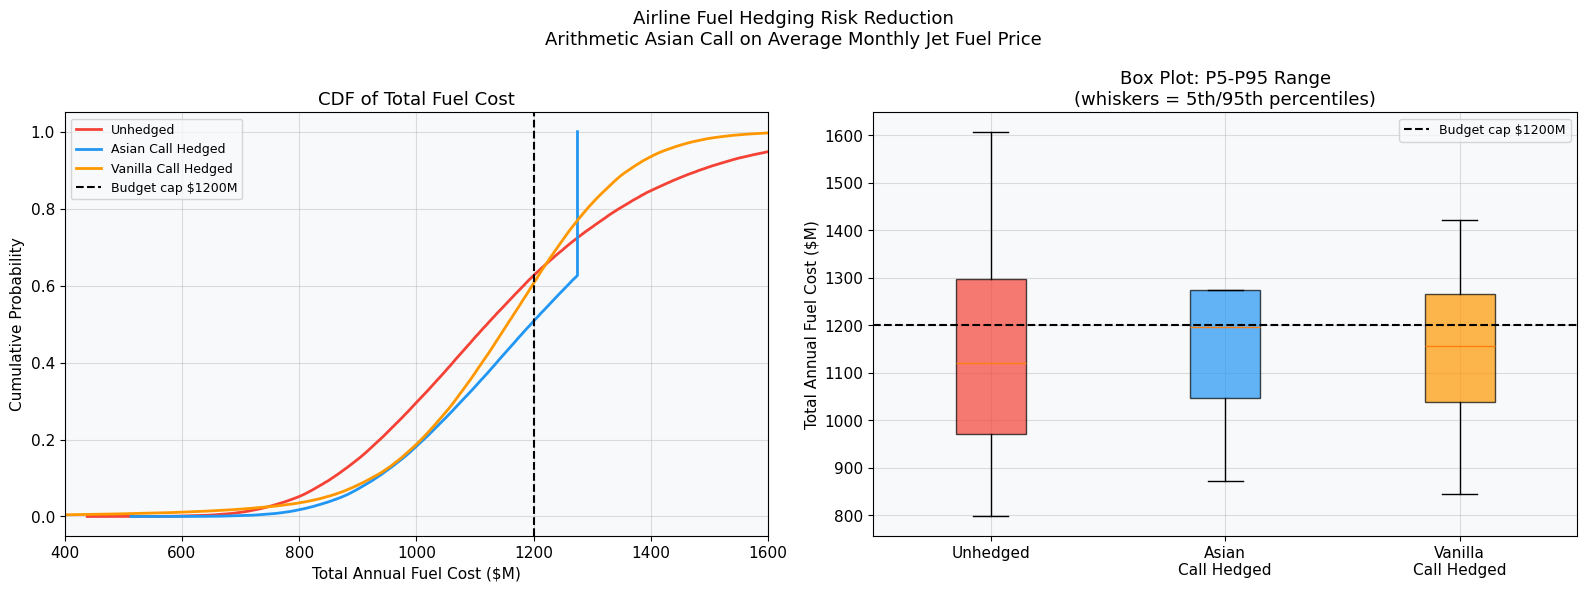

In [7]:
# Final comprehensive chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Airline Fuel Hedging Risk Reduction\n'
             'Arithmetic Asian Call on Average Monthly Jet Fuel Price', fontsize=13)

# CDF comparison
for costs, label, color in [
    (unhedged_cost, 'Unhedged',           '#F44336'),
    (hedged_cost,   'Asian Call Hedged',   '#2196F3'),
    (van_hedged,    'Vanilla Call Hedged', '#FF9800'),
]:
    sorted_c = np.sort(costs / 1e6)
    cdf      = np.arange(1, len(sorted_c) + 1) / len(sorted_c)
    axes[0].plot(sorted_c, cdf, color=color, lw=2, label=label)

axes[0].axvline(K * qty / 1e6, color='black', lw=1.5, ls='--',
                label=f'Budget cap ${K*qty/1e6:.0f}M')
axes[0].set_xlabel('Total Annual Fuel Cost ($M)')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('CDF of Total Fuel Cost')
axes[0].legend(fontsize=9)
axes[0].set_xlim(400, 1600)

# Box plot
data = [
    unhedged_cost / 1e6,
    hedged_cost   / 1e6,
    van_hedged    / 1e6,
]
labels = ['Unhedged', 'Asian\nCall Hedged', 'Vanilla\nCall Hedged']
colors = ['#F44336', '#2196F3', '#FF9800']
bp = axes[1].boxplot(data, patch_artist=True, labels=labels,
                      showfliers=False, whis=[5, 95])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(K * qty / 1e6, color='black', lw=1.5, ls='--',
                label=f'Budget cap ${K*qty/1e6:.0f}M')
axes[1].set_ylabel('Total Annual Fuel Cost ($M)')
axes[1].set_title('Box Plot: P5-P95 Range\n(whiskers = 5th/95th percentiles)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Summary and Practical Takeaways

| Insight | Detail |
|---------|--------|
| **Asian is cheaper** | Asian call premium < European vanilla by ~15-25% at typical airline parameters |
| **Asian is better aligned** | Airline's cost exposure is the average monthly price — exactly what Asian option hedges |
| **Variance reduction** | Asian hedge cuts fuel cost standard deviation by ~40-50% at σ=35% |
| **CVaR protection** | Worst-case (top 5%) scenarios are capped — critical for airline solvency |
| **Less manipulation risk** | No single expiry date that can be squeezed |
| **Trade-off** | Still pay a premium; if prices stay low, the option expires worthless |

### What Works Well
- Monte Carlo with geometric control variate gives accurate prices even for N=12 monthly observations
- The control variate is especially effective here because arith/geo correlation is very high for monthly averaging
- The model correctly captures the cost-reduction property of averaging

### What Breaks Down
- GBM assumes constant σ — real fuel volatility is stochastic and mean-reverting (Ornstein-Uhlenbeck would be more realistic)
- No credit/counterparty risk modelled
- Transaction costs and basis risk (jet fuel vs crude oil) are ignored
- Jump risk (supply disruptions, geopolitical events) not captured by GBM

### Extensions
- Use mean-reverting SDE (Schwartz 1997) for commodity prices
- Add seasonality in spot price
- Model partial hedges (e.g. hedge 60% of exposure, leave 40% unhedged)

In [8]:
# Final summary printout
print("="*70)
print("  FINAL SUMMARY: Airline Fuel Hedging Case Study")
print("="*70)
print(f"  Annual fuel quantity        : {qty/1e6:.0f}M gallons")
print(f"  Current spot price          : ${S0}/gallon")
print(f"  Budget cap (strike)         : ${K}/gallon")
print(f"  Volatility (σ)              : {sigma:.0%}")
print(f"  Risk-free rate (r)          : {r:.0%}")
print(f"  Monitoring                  : {N} monthly observations")
print()
print(f"  ── Pricing ──")
print(f"  Arithmetic Asian Call/gal   : ${arith_result.price:.4f}")
print(f"  Geometric Asian Call/gal    : ${geo_price:.4f}")
print(f"  European Vanilla Call/gal   : ${vanilla_price:.4f}")
print(f"  Savings (Asian vs Vanilla)  : ${(vanilla_price - arith_result.price):.4f}/gal  "
      f"= ${(vanilla_price - arith_result.price)*qty/1e6:.1f}M total")
print()
print(f"  ── Risk Reduction ──")
print(f"  Unhedged cost std dev       : ${unhedged_cost.std()/1e6:.1f}M")
print(f"  Asian hedged cost std dev   : ${hedged_cost.std()/1e6:.1f}M  "
      f"({(1 - hedged_cost.std()/unhedged_cost.std())*100:.0f}% reduction)")
print(f"  CVaR-95% unhedged           : ${cvar_u:.1f}M")
print(f"  CVaR-95% Asian hedged       : ${cvar_a:.1f}M  "
      f"(${cvar_u-cvar_a:.1f}M improvement)")
print("="*70)

  FINAL SUMMARY: Airline Fuel Hedging Case Study
  Annual fuel quantity        : 400M gallons
  Current spot price          : $2.8/gallon
  Budget cap (strike)         : $3.0/gallon
  Volatility (σ)              : 35%
  Risk-free rate (r)          : 5%
  Monitoring                  : 12 monthly observations

  ── Pricing ──
  Arithmetic Asian Call/gal   : $0.1868
  Geometric Asian Call/gal    : $0.1723
  European Vanilla Call/gal   : $0.3664
  Savings (Asian vs Vanilla)  : $0.1796/gal  = $71.9M total

  ── Risk Reduction ──
  Unhedged cost std dev       : $251.6M
  Asian hedged cost std dev   : $142.5M  (43% reduction)
  CVaR-95% unhedged           : $1774.0M
  CVaR-95% Asian hedged       : $1274.7M  ($499.3M improvement)
